# 2. Preprocessing

In [15]:
from chess_eval import *
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

dm = DataManager(
    filepath=DATASET_FILE,
    read_size=READ_SIZE,
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)
df = dm.df_raw

In [16]:
df[df[EVAL].str[0] == "#"]

,FEN,Evaluation
59,7k/p1r2b2/4pq2/1p1p1nR1/5P2/P2B4/1P2Q2P/1K4R1 ...,#+6
60,7k/p1r2b2/4pq2/1p1p1BR1/5P2/P7/1P2Q2P/1K4R1 b ...,#+6
61,7k/p1r2b2/5q2/1p1p1pR1/5P2/P7/1P2Q2P/1K4R1 w -...,#+4
62,7k/p1r2b2/5q2/1p1p1p1R/5P2/P7/1P2Q2P/1K4R1 b -...,#+3


In [19]:
df = df[~df[EVAL].astype(str).str.contains("#")]
df[df[EVAL].str[0] == "#"]

,FEN,Evaluation


In [20]:
df.loc[:, EVAL] = pd.to_numeric(df[EVAL], errors="coerce").astype(int)

We also see the evaluation has a vast range of values, but most of them are accumulated around zero.

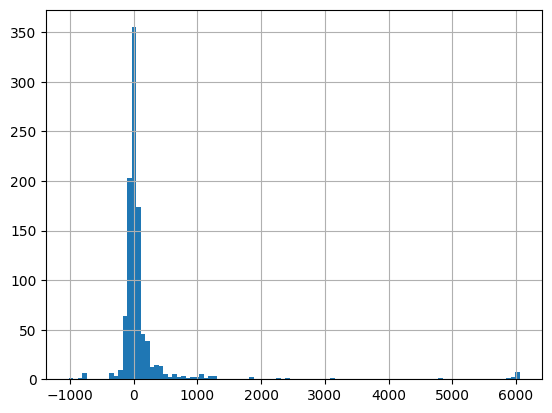

In [21]:
df[EVAL].hist(bins=100)
plt.show()

So we want to either clip them to a maximum (say 1000) or consider them outliers and remove them from the training dataset. For now, we will consider the dataset clipped at 1000.

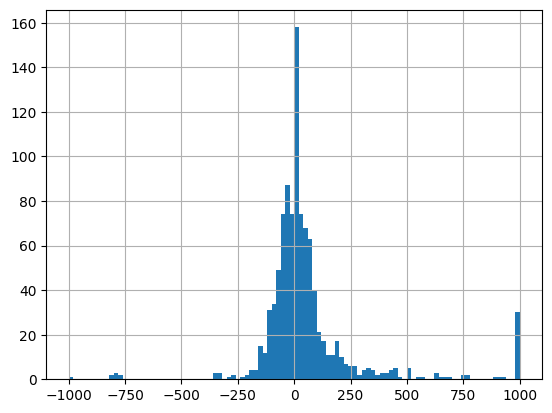

In [24]:
df.loc[:, EVAL] = np.clip(df[EVAL], -1000, 1000)
df[EVAL].hist(bins=100)
plt.show()

Summary: use this `clean` function.

In [25]:
def clean(df: pd.DataFrame, mode: str = "remove", threshold: int = 1000) -> pd.DataFrame:
    df = df[~df[EVAL].astype(str).str.contains("#")]
    df.loc[:, EVAL] = pd.to_numeric(df[EVAL], errors="coerce").astype(int)
    if mode == "clip":
        df.loc[:, EVAL] = np.clip(df[EVAL], -threshold, threshold)
    elif mode == "remove":
        df = df[df[EVAL].abs() <= threshold]
    else:
        raise ValueError("mode must be 'clip' or 'remove'")
    return df

In [26]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 996 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   FEN         996 non-null    object
 1   Evaluation  996 non-null    object
dtypes: object(2)
memory usage: 147.2 KB
